## 所谓二元语言模型，就是每次关注两个连续元素。

一句话理解就是：
> 只看前一个符号，来预测下一个符号。

In [1]:
words = open('../names.txt', 'r').read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
print(min(len(w) for w in words), max(len(w) for w in words))

2 15


In [4]:
words[0:1]

['emma']

In [5]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] # 让二元模型学习一个单词如何开始，如何结束
    for ch1, ch2 in zip(chs, chs[1:]): # w="emma", w[1:]="mma"
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [6]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

太惭愧了，复习一下字典吧：
```
b.keys()     # 只拿 key
b.values()   # 只拿 value
b.items()    # 拿 (key, value)
```

lambda 参数: 返回值

In [7]:
import torch

In [8]:
a = torch.zeros((3,5), dtype = torch.int32)
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [9]:
a[0, 3] += 1

In [10]:
a

tensor([[0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [29]:
N = torch.zeros((28, 28), dtype = torch.int32)
chars = sorted(list(set(''.join(words)))) # 把 words 这个字符串列表里的所有单词，拼接成一个大字符串，中间不加任何东西。
stoi = {s:i for i,s in enumerate(chars)}  # stoi = string to integer
stoi['<S>'] = 26
stoi['<E>'] = 27

for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] 
    for ch1, ch2 in zip(chs, chs[1:]): 
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1  # point


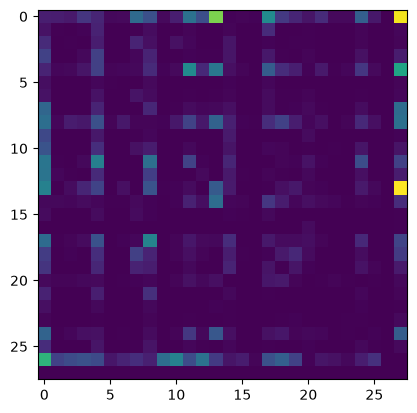

In [30]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N) 

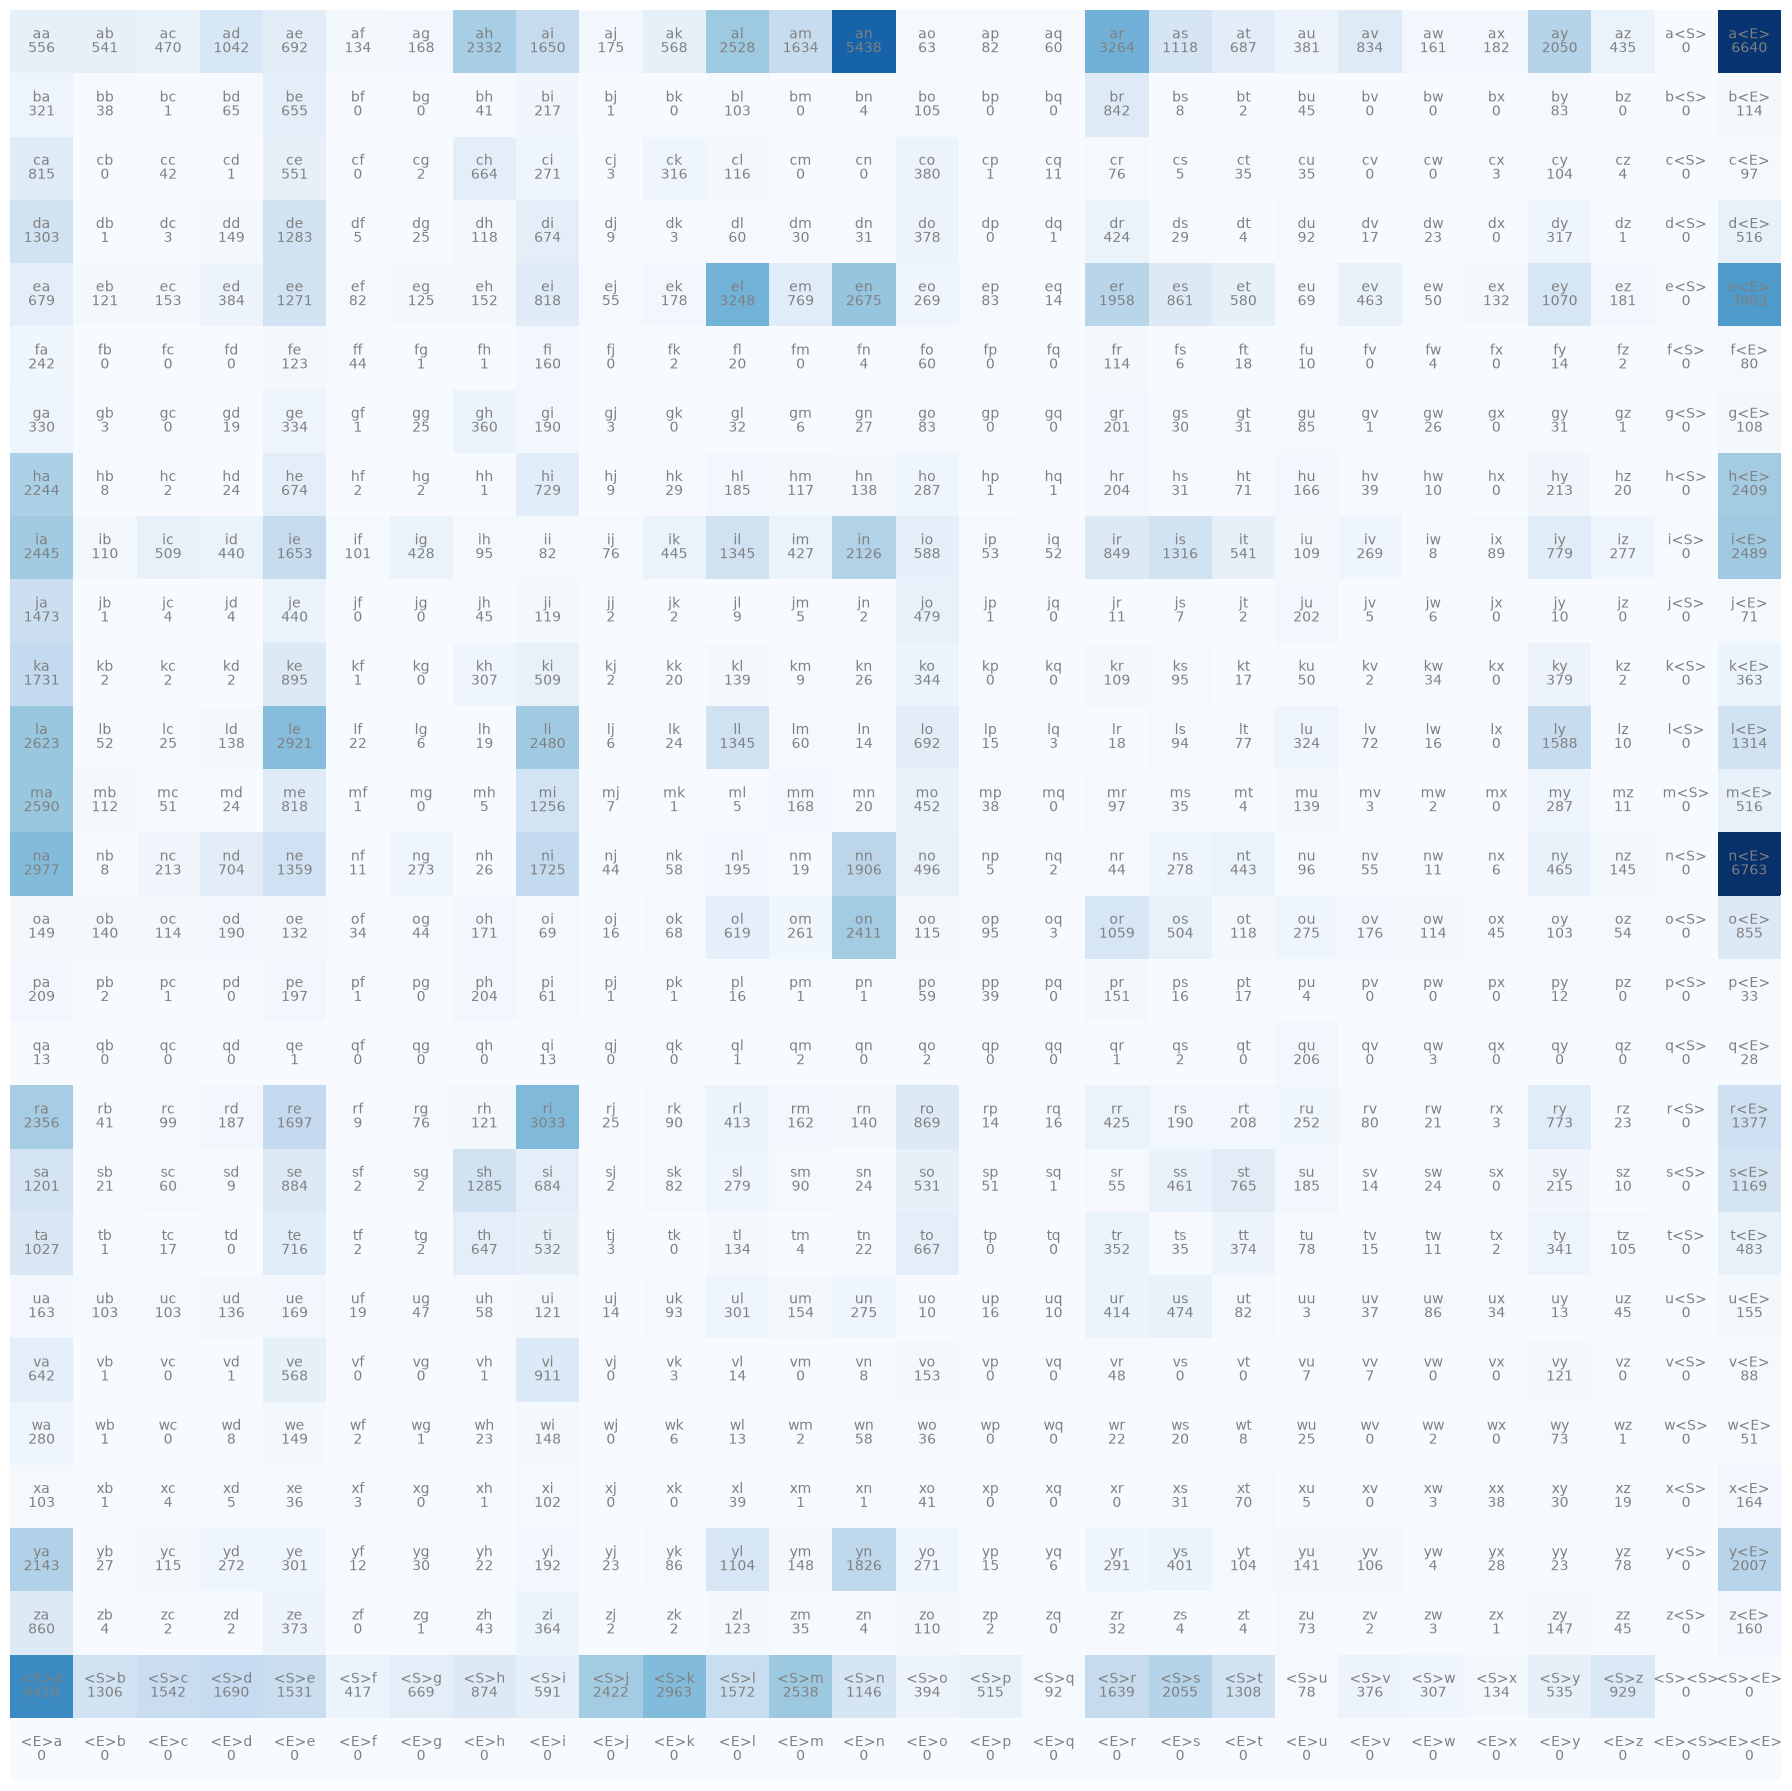

In [ ]:
# 图表优化
itos = {i:s for s, i in stoi.items()}

import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize = (23,23))
plt.imshow(N, cmap = 'Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha = "center", va = "bottom", color = 'gray')
        plt.text(j, i, N[i, j].item(), ha = "center", va = "top", color = "gray")
plt.axis('off');  # 不显示坐标轴

In [27]:
# 解释 N[i, j].item()
print(N[3, 3], N[3, 3].item())
print(type(N[3, 3]), type(N[3, 3].item()))

tensor(149, dtype=torch.int32) 149
<class 'torch.Tensor'> <class 'int'>
